In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, models, transforms
import numpy as np
import time

In [2]:
import torch
import torch.nn as nn
import torchvision.models as models

num_classes = 14
device = "cuda" if torch.cuda.is_available() else "cpu"


def create_model():

    model = models.convnext_small(pretrained=True)

    # classifier 변경
    model.classifier[2] = nn.Linear(768, num_classes)

    # 모든 layer freeze
    for param in model.parameters():
        param.requires_grad = False

    # classifier 학습
    for param in model.classifier.parameters():
        param.requires_grad = True

    # backbone 일부 학습
    for param in model.features[-2:].parameters():
        param.requires_grad = True

    model = model.to(device)

    return model


print("cuda => ", torch.cuda.is_available())

cuda =>  True


In [3]:
from torchvision import datasets, models, transforms

transform_train = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.RandomRotation(2),
        transforms.RandomAffine(degrees=0, translate=(0.02, 0.02)),
        transforms.RandomPerspective(distortion_scale=0.05, p=0.3),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.9367, 0.9364, 0.9358], [0.0957, 0.0964, 0.0963]),
    ]
)
transform_test = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.9367, 0.9364, 0.9358], [0.0957, 0.0964, 0.0963]),
    ]
)

In [4]:
import torch
from torch.utils.data import Dataset
import pandas as pd
from PIL import Image
import os


class MultiLabelDataset(Dataset):

    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

        self.labels = self.data.iloc[:, 1:].values

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        img_path = os.path.join(self.img_dir, self.data.iloc[idx, 0])
        image = Image.open(img_path).convert("RGB")

        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label

In [5]:
NUM_CLASSES = 14

train_dataset = MultiLabelDataset(
    csv_file=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2-4000\train_labels_4000.csv",
    img_dir=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2-4000\train_4000",
    transform=transform_train,
)

val_dataset = MultiLabelDataset(
    csv_file=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2-4000\val_labels_4000.csv",
    img_dir=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2-4000\val_4000",
    transform=transform_test,
)

test_dataset = MultiLabelDataset(
    csv_file=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2-4000\test_labels_4000.csv",
    img_dir=r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2-4000\test_4000",
    transform=transform_test,
)

In [6]:
len(train_dataset)

2799

In [7]:
import pandas as pd
import torch

df = pd.read_csv(
    r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2-4000\train_labels_4000.csv"
)

labels = df.iloc[:, 1:].values

pos_counts = labels.sum(axis=0)
neg_counts = labels.shape[0] - pos_counts

pos_weight = neg_counts / pos_counts

pos_weight = torch.tensor(pos_weight, dtype=torch.float32).to(device)

In [16]:
import os
import torch
import torch.optim as optim
import torch.nn as nn
import optuna
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

os.makedirs("checkpoints", exist_ok=True)


def objective(trial):

    model = create_model()

    batch_size = trial.suggest_categorical("batch_size", [6, 8])
    lr = trial.suggest_float("lr", 4e-4, 1e-3, log=True)

    writer = SummaryWriter(
        log_dir=f"runs/optuna_trial_{trial.number}",
        flush_secs=5
    )
    train_dataloader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True
    )

    val_dataloader = torch.utils.data.DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False
    )

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    epochs = 15
    best_val_loss = float("inf")

    tensorboard_count = 0

    epoch_bar = tqdm(range(epochs), desc=f"Trial {trial.number}")

    for epoch in epoch_bar:

        # -----------------
        # Train
        # -----------------
        model.train()

        for img, labels in tqdm(train_dataloader, leave=False):

            img = img.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            preds = model(img)

            loss = criterion(preds, labels)

            # batch 기준 기록 (기존 코드와 동일)
            writer.add_scalar("Loss/Train", loss.item(), tensorboard_count)

            tensorboard_count += 1

            loss.backward()
            optimizer.step()

        # -----------------
        # Validation
        # -----------------
        model.eval()

        val_loss = 0

        with torch.no_grad():

            for img, labels in val_dataloader:

                img = img.to(device)
                labels = labels.to(device)

                preds = model(img)

                loss = criterion(preds, labels)

                val_loss += loss.item()

        total_val_loss = val_loss / len(val_dataloader)

        # epoch 기준 validation 기록
        writer.add_scalar("Loss/Validation", total_val_loss, epoch)

        epoch_bar.set_postfix(val_loss=total_val_loss)

        trial.report(total_val_loss, epoch)

        if total_val_loss < best_val_loss:

            best_val_loss = total_val_loss

            torch.save(
                model.state_dict(),
                f"checkpoints/optuna_trial_{trial.number}_best.pth",
            )

        if trial.should_prune():
            writer.close()
            raise optuna.exceptions.TrialPruned()

    writer.close()

    return best_val_loss


study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=25)

print("Best trial:", study.best_trial.number)
print("Best params:", study.best_trial.params)

[I 2026-03-10 11:46:45,508] A new study created in memory with name: no-name-6c220b9e-9b39-4701-8bd6-23b719a0a920
c:\potenup3\TEAM-PJ-DEEP\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\potenup3\TEAM-PJ-DEEP\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Small_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Trial 0: 100%|██████████| 15/15 [33:13<00:00, 132.91s/it, val_loss=0.00977]
[I 2026-03-10 12:19:59,807] Trial 0 finished with value: 0.009771243260474875 and parameters: {'batch_size': 6, 'lr': 0.0004856903881153548}. Best is trial 0

KeyboardInterrupt: 

In [24]:
import pickle

with open("optuna_study.pkl", "wb") as f:
    pickle.dump(study, f)

In [1]:
import pickle

with open("optuna_study.pkl", "rb") as f:
    study = pickle.load(f)

In [2]:
import optuna.visualization as vis

vis.plot_optimization_history(study)
vis.plot_param_importances(study)
vis.plot_slice(study)

In [15]:
model_path = r"C:\potenup3\TEAM-PJ-DEEP\document_forms_source\checkpoints\optuna_trial_8_best_val_loss_0.00836.pth"

state_dict = torch.load(model_path, map_location="cuda")
model.load_state_dict(state_dict)

<All keys matched successfully>

In [9]:
model.to("cuda")

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [17]:
image = Image.open(
    r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2\test\학습-전입신고서15.jpg"
).convert("RGB")


input_tensor_image = transform_test(image).to(device)

model.eval()

with torch.no_grad():

    output = model(input_tensor_image.unsqueeze(0).cuda())

    probs = torch.sigmoid(output)

    print(probs)

    preds = (probs > 0.5).int()

print(preds)

tensor([[0.0314, 0.9981, 0.0014, 0.9815, 0.9970, 0.6593, 0.8374, 0.9996, 0.9998,
         0.9973, 0.6029, 0.0974, 0.5847, 0.5176]], device='cuda:0')
tensor([[0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1]], device='cuda:0',
       dtype=torch.int32)


In [18]:
import matplotlib.pyplot as plt
import torch


def imshow(img, title):
    mean = torch.tensor([0.9367, 0.9364, 0.9358])
    std = torch.tensor([0.0957, 0.0964, 0.0963])

    img = img.permute(1, 2, 0)
    img = img * std + mean
    img = img.clamp(0, 1)

    plt.title(title)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [19]:
import torch
import torchvision
from sklearn.metrics import f1_score, average_precision_score

model.eval()

all_preds = []
all_labels = []
all_probs = []

test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=8, shuffle=False)

with torch.no_grad():
    corrects = 0
    total = 0

    for img, labels in test_dataloader:

        img = img.to(device)
        labels = labels.to(device)

        preds = model(img)
        probs = torch.sigmoid(preds)
        pred = probs > 0.5  # 멀티라벨 예측

        corrects += (pred == labels.bool()).sum().item()
        total += labels.numel()

        # metric 계산용 저장
        all_preds.append(pred.cpu())
        all_labels.append(labels.cpu())
        all_probs.append(probs.cpu())

    acc = corrects / total

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_probs = torch.cat(all_probs).numpy()

    # F1 score
    f1_micro = f1_score(all_labels, all_preds, average="micro")
    f1_macro = f1_score(all_labels, all_preds, average="macro")
    f1_weighted = f1_score(all_labels, all_preds, average="weighted")

    # mAP (mean average precision)
    mAP = average_precision_score(all_labels, all_probs, average="macro")

    print(f"정확도 : {acc:.4f}")
    print(f"F1 micro : {f1_micro:.4f}")
    print(f"F1 macro : {f1_macro:.4f}")
    print(f"F1 weighted : {f1_weighted:.4f}")
    print(f"mAP : {mAP:.4f}")

정확도 : 0.9457
F1 micro : 0.9616
F1 macro : 0.9673
F1 weighted : 0.9559
mAP : 0.9998


In [ ]:
model.eval()

with torch.no_grad():
    corrects = 0
    total = 0

    for img, labels in test_dataloader:

        img = img.to(device)
        labels = labels.to(device)

        preds = model(img)
        probs = torch.sigmoid(preds)
        pred = probs > 0.5  # 멀티라벨 예측

        corrects += (pred == labels.bool()).sum().item()
        total += labels.numel()

        img_grid = torchvision.utils.make_grid(img.cpu())

        imshow(img_grid, title=(pred.cpu(), labels.cpu()))

    acc = corrects / total
    print("정확도 :", acc)

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

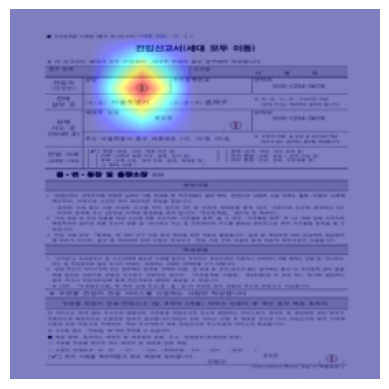

In [20]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

model.eval()
model.to("cuda")

img = Image.open(
    r"C:\potenup3\TEAM-PJ-DEEP\document_forms_data\data2\test\학습-전입신고서15.jpg"
).convert("RGB")
input_tensor = transform_test(img).unsqueeze(0).to("cuda")

# 마지막 stage grad 활성화
for param in model.features[-1].parameters():
    param.requires_grad = True

pred = model(input_tensor)

target_class = 1

target_layers = [model.features[-1][-1]]

cam = GradCAM(model=model, target_layers=target_layers)

grad_cam = cam(
    input_tensor=input_tensor, targets=[ClassifierOutputTarget(target_class)]
)[0]

rgb_img = np.array(img.resize((224, 224))).astype(np.float32) / 255.0
visualization = show_cam_on_image(rgb_img, grad_cam, use_rgb=True)

plt.imshow(visualization)
plt.axis("off")